<a href="https://colab.research.google.com/github/tharun-ragu22/rideshare-predictor/blob/main/RideshareML_TrainModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Get and pre-process data

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv(
    r'/content/final_data.csv',
    parse_dates=['pickup_hr'],
    lineterminator="\n",  # force consistent line ending
    low_memory=False,      # prevents mixed-type inference across chunks
    )
df.shape

(6337256, 10)

In [ ]:
print(df.memory_usage(deep=True).sum() / 1e9, "GB")

0.79226581 GB


In [ ]:
df.head()

,pickup_hr,pickup_ward,dropoff_ward,total_time,Temp (°C),Precip. Amount (mm),Visibility (km),event_in_pickup_ward,event_type,audience
0,2023-01-01,10,10,25.28,4.0,0.0,16.1,0,none,0
1,2023-01-01,10,11,23.93,4.0,0.0,16.1,0,none,0
2,2023-01-01,11,10,22.32,4.0,0.0,16.1,0,none,0
3,2023-01-01,10,13,31.93,4.0,0.0,16.1,0,none,0
4,2023-01-01,13,10,30.51,4.0,0.0,16.1,0,none,0


In [ ]:
df["hour"] = df["pickup_hr"].dt.hour
df["day_of_week"] = df["pickup_hr"].dt.dayofweek   # 0=Mon, 6=Sun
df["day"] = df["pickup_hr"].dt.day
df["month"] = df["pickup_hr"].dt.month
df["year"] = df["pickup_hr"].dt.year


df = df.drop(columns=["pickup_hr"])
df.head()

,pickup_ward,dropoff_ward,total_time,Temp (°C),Precip. Amount (mm),Visibility (km),event_in_pickup_ward,event_type,audience,hour,day_of_week,day,month,year
0,10,10,25.28,4.0,0.0,16.1,0,none,0,0,6,1,1,2023
1,10,11,23.93,4.0,0.0,16.1,0,none,0,0,6,1,1,2023
2,11,10,22.32,4.0,0.0,16.1,0,none,0,0,6,1,1,2023
3,10,13,31.93,4.0,0.0,16.1,0,none,0,0,6,1,1,2023
4,13,10,30.51,4.0,0.0,16.1,0,none,0,0,6,1,1,2023


In [ ]:
df['event_type'] = df['event_type'].replace('baseball', 'sport')

categorical_cols = ["pickup_ward", "dropoff_ward", "event_type"]

# Make sure they're int32 (ward columns already are; encode event_type first)
df["event_type"] = df["event_type"].astype("category").cat.codes  # converts strings to ints
for col in categorical_cols:
    df[col] = df[col].astype("int32")

display(df.head())

,pickup_ward,dropoff_ward,total_time,Temp (°C),Precip. Amount (mm),Visibility (km),event_in_pickup_ward,event_type,audience,hour,day_of_week,day,month,year
0,10,10,25.28,4.0,0.0,16.1,0,0,0,0,6,1,1,2023
1,10,11,23.93,4.0,0.0,16.1,0,0,0,0,6,1,1,2023
2,11,10,22.32,4.0,0.0,16.1,0,0,0,0,6,1,1,2023
3,10,13,31.93,4.0,0.0,16.1,0,0,0,0,6,1,1,2023
4,13,10,30.51,4.0,0.0,16.1,0,0,0,0,6,1,1,2023


In [ ]:
df.shape

(6337256, 14)

In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6337256 entries, 0 to 6337255
Data columns (total 14 columns):
 #   Column                Dtype  
---  ------                -----  
 0   pickup_ward           int32  
 1   dropoff_ward          int32  
 2   total_time            float64
 3   Temp (°C)             float64
 4   Precip. Amount (mm)   float64
 5   Visibility (km)       float64
 6   event_in_pickup_ward  int64  
 7   event_type            int32  
 8   audience              int64  
 9   hour                  int32  
 10  day_of_week           int32  
 11  day                   int32  
 12  month                 int32  
 13  year                  int32  
dtypes: float64(4), int32(8), int64(2)
memory usage: 483.5 MB


None

In [ ]:
display(df['Temp (°C)'].describe())

display(df['Precip. Amount (mm)'].describe())

display(df['Visibility (km)'].describe())

,Temp (°C)
count,6.337256e+06
mean,9.931539e+00
std,1.001565e+01
min,-2.000000e+01
25%,2.000000e+00
50%,9.400000e+00
75%,1.910000e+01
max,3.440000e+01


,Precip. Amount (mm)
count,6.337256e+06
mean,8.410610e-02
std,6.463675e-01
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,4.370000e+01


,Visibility (km)
count,6.337256e+06
mean,1.518552e+01
std,2.966792e+00
min,0.000000e+00
25%,1.610000e+01
50%,1.610000e+01
75%,1.610000e+01
max,1.610000e+01


In [ ]:
df['year'].value_counts()

,count
year,
2025,1459405
2024,1316610
2023,1130189
2022,883069
2021,658720
2020,650900
2026,238363


In [ ]:
df.corr().style.background_gradient(cmap='coolwarm')


,pickup_ward,dropoff_ward,total_time,Temp (°C),Precip. Amount (mm),Visibility (km),event_in_pickup_ward,event_type,audience,hour,day_of_week,day,month,year
pickup_ward,1.000000,0.763936,-0.100003,-0.007234,0.002657,-0.002696,-0.021284,-0.021284,-0.020651,0.022282,-0.020036,0.000727,-0.006180,0.035831
dropoff_ward,0.763936,1.000000,-0.100844,-0.006560,0.002699,-0.002340,-0.010929,-0.010929,-0.010686,0.027796,-0.018819,0.000448,-0.006481,0.033418
total_time,-0.100003,-0.100844,1.000000,0.062581,0.018992,-0.016210,0.065295,0.065295,0.066601,0.082406,0.040741,0.018577,0.057639,0.209561
Temp (°C),-0.007234,-0.006560,0.062581,1.000000,0.018865,0.119449,0.018866,0.018866,0.026772,0.052471,-0.007306,-0.001071,0.339141,-0.089925
Precip. Amount (mm),0.002657,0.002699,0.018992,0.018865,1.000000,-0.241204,-0.000715,-0.000715,-0.000611,0.002016,-0.015224,0.011321,0.001410,-0.010592
Visibility (km),-0.002696,-0.002340,-0.016210,0.119449,-0.241204,1.000000,0.004548,0.004548,0.004565,0.021930,-0.001176,-0.021463,0.048056,-0.026128
event_in_pickup_ward,-0.021284,-0.010929,0.065295,0.018866,-0.000715,0.004548,1.000000,1.000000,0.970275,0.069375,-0.000573,0.006004,-0.004218,0.025677
event_type,-0.021284,-0.010929,0.065295,0.018866,-0.000715,0.004548,1.000000,1.000000,0.970275,0.069375,-0.000573,0.006004,-0.004218,0.025677
audience,-0.020651,-0.010686,0.066601,0.026772,-0.000611,0.004565,0.970275,0.970275,1.000000,0.066578,-0.000266,0.006785,-0.004087,0.025826
hour,0.022282,0.027796,0.082406,0.052471,0.002016,0.021930,0.069375,0.069375,0.066578,1.000000,-0.041073,0.006258,0.003625,-0.023822


In [ ]:
df.shape

(6337256, 14)

# Split Data

In [ ]:
target_variable = 'total_time'

y = df[target_variable]
X = df.loc[:, df.columns != target_variable]

display(X.head())
display(y.head())

,pickup_ward,dropoff_ward,Temp (°C),Precip. Amount (mm),Visibility (km),event_in_pickup_ward,event_type,audience,hour,day_of_week,day,month,year
0,10,10,4.0,0.0,16.1,0,0,0,0,6,1,1,2023
1,10,11,4.0,0.0,16.1,0,0,0,0,6,1,1,2023
2,11,10,4.0,0.0,16.1,0,0,0,0,6,1,1,2023
3,10,13,4.0,0.0,16.1,0,0,0,0,6,1,1,2023
4,13,10,4.0,0.0,16.1,0,0,0,0,6,1,1,2023


,total_time
0,25.28
1,23.93
2,22.32
3,31.93
4,30.51


In [ ]:
y.shape

(6337256,)

In [ ]:
X.shape

(6337256, 13)

In [ ]:
from sklearn.model_selection import train_test_split
RNG_SEED = 18
TEST_SIZE = 0.15
VALIDATION_SIZE = 0.1/(1-TEST_SIZE)

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size = TEST_SIZE, random_state=RNG_SEED)

X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size = VALIDATION_SIZE, random_state=RNG_SEED)

display(X_train.head())

display(y_train.head())

,pickup_ward,dropoff_ward,Temp (°C),Precip. Amount (mm),Visibility (km),event_in_pickup_ward,event_type,audience,hour,day_of_week,day,month,year
4963517,13,13,22.2,0.0,16.1,0,0,0,10,2,12,8,2020
5817991,18,11,15.3,0.0,16.1,0,0,0,10,5,4,5,2024
4147084,5,6,-3.9,0.2,2.8,0,0,0,20,3,18,2,2021
829661,12,10,19.3,0.0,16.1,0,0,0,2,6,23,7,2023
4290304,12,11,20.2,0.0,16.1,0,0,0,20,4,10,9,2021


,total_time
4963517,9.18
5817991,38.50
4147084,16.83
829661,22.04
4290304,18.65


In [ ]:
X_train.shape[0]+X_test.shape[0]+X_val.shape[0] == df.shape[0]

True

In [ ]:
print("train proportion: ", X_train.shape[0]/X.shape[0])
print("val proportion: ", X_val.shape[0]/X.shape[0])
print("test proportion: ", X_test.shape[0]/X.shape[0])

train proportion:  0.7499998422029976
val proportion:  0.10000006311880094
test proportion:  0.1500000946782014


<Figure size 1200x700 with 0 Axes>

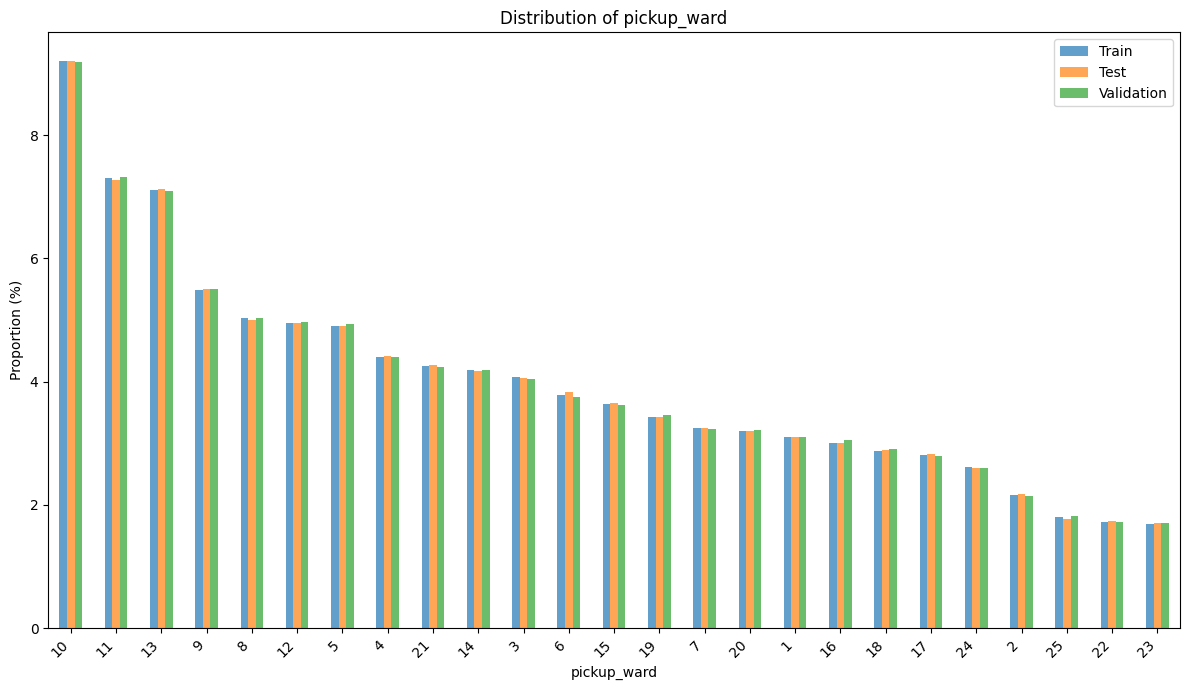

<Figure size 1200x700 with 0 Axes>

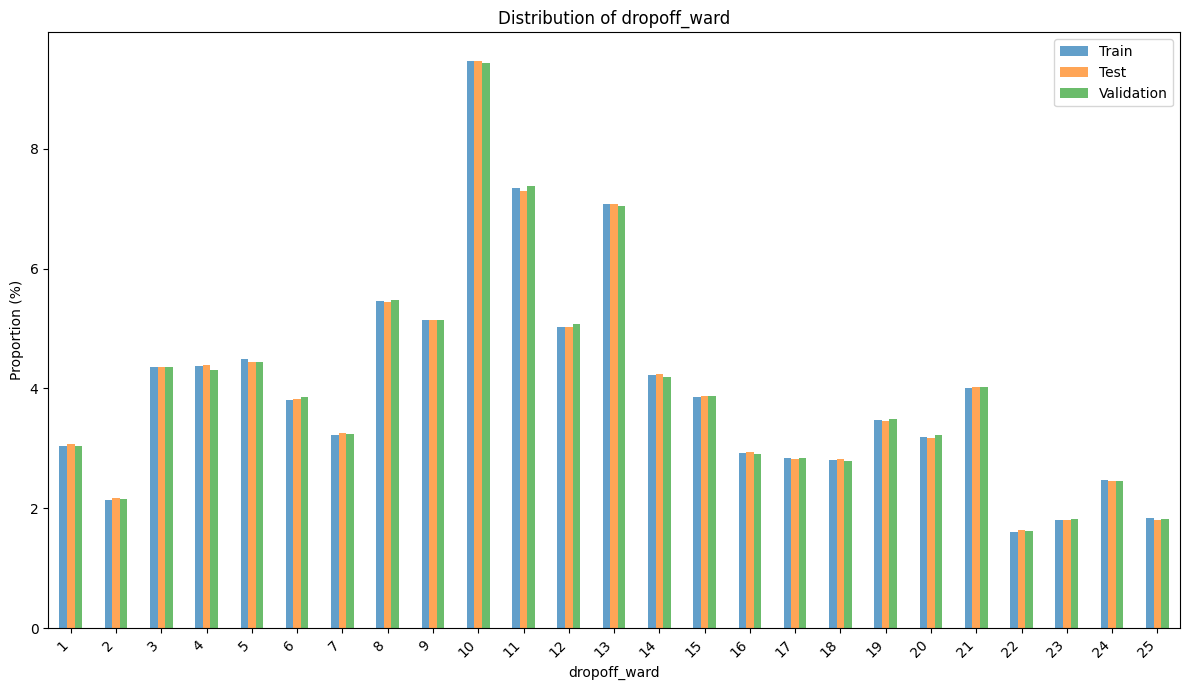

<Figure size 1200x700 with 0 Axes>

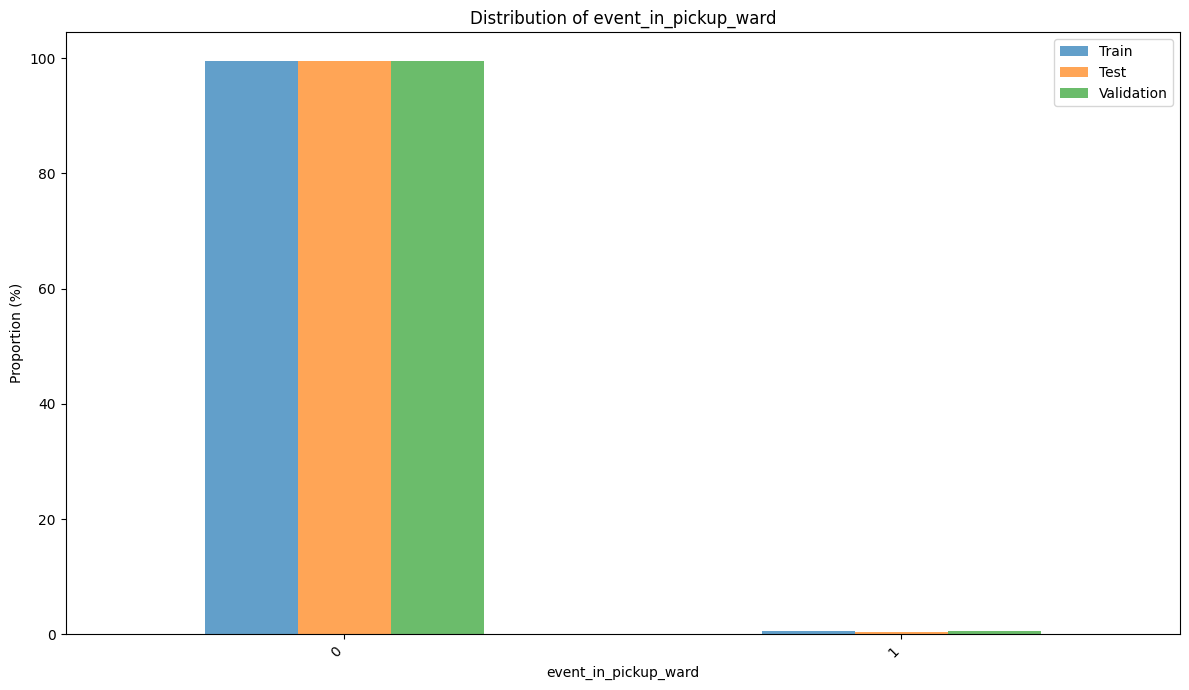

<Figure size 1200x700 with 0 Axes>

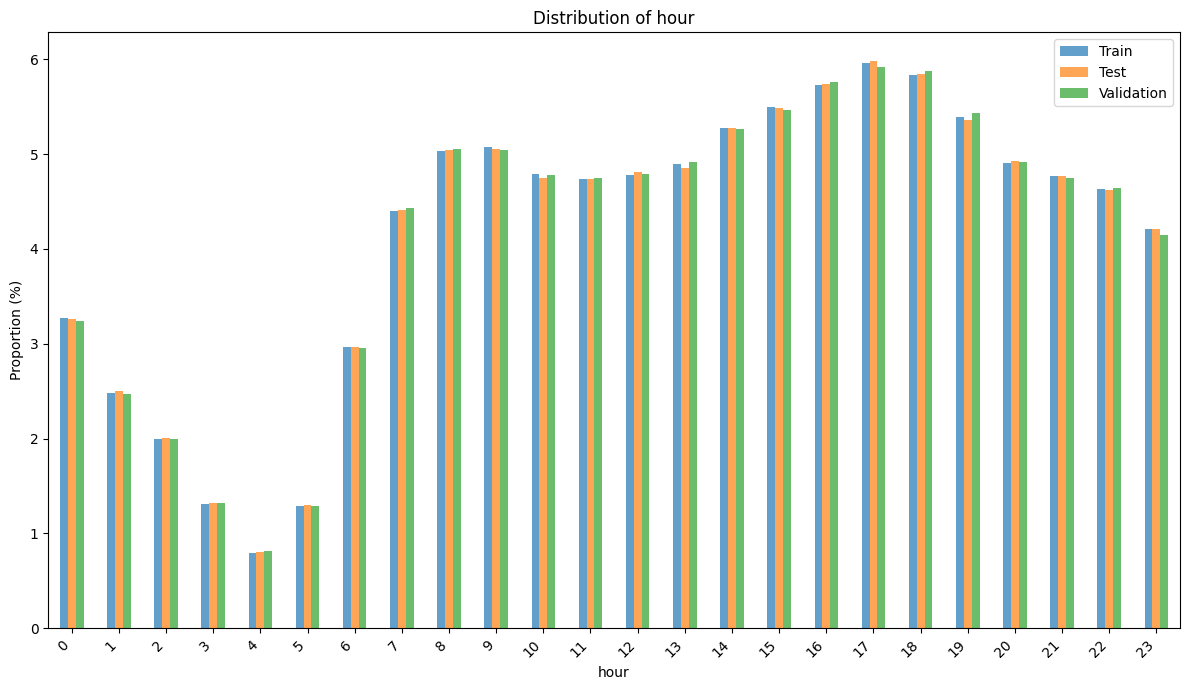

<Figure size 1200x700 with 0 Axes>

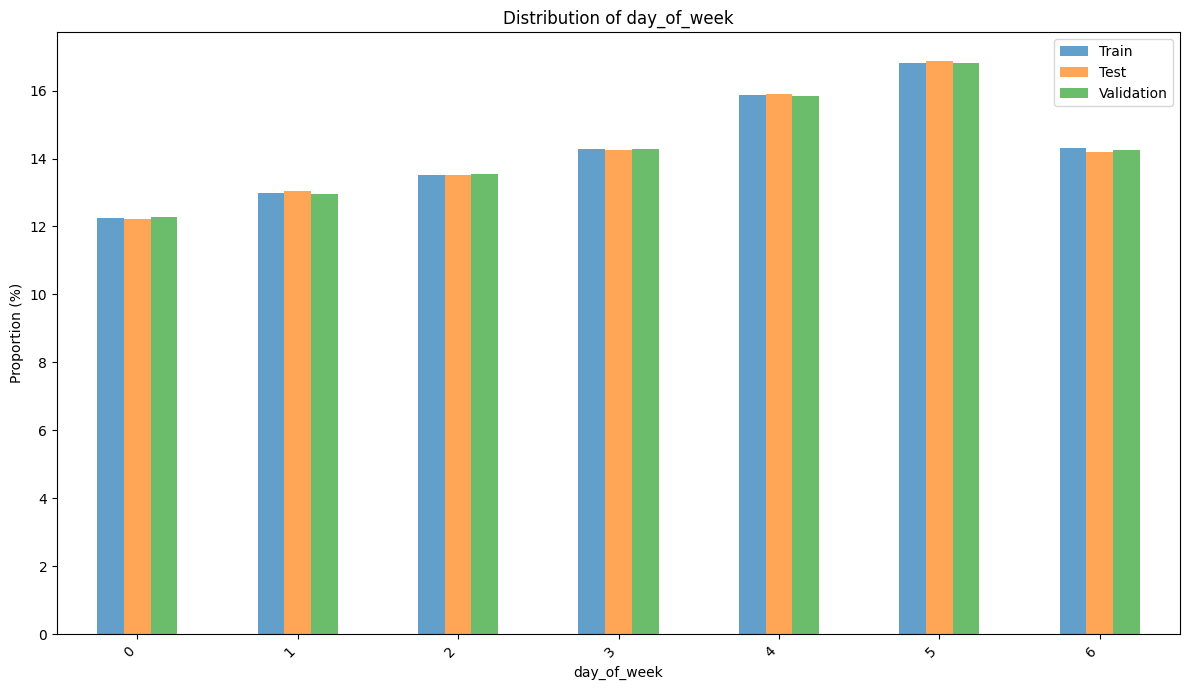

<Figure size 1200x700 with 0 Axes>

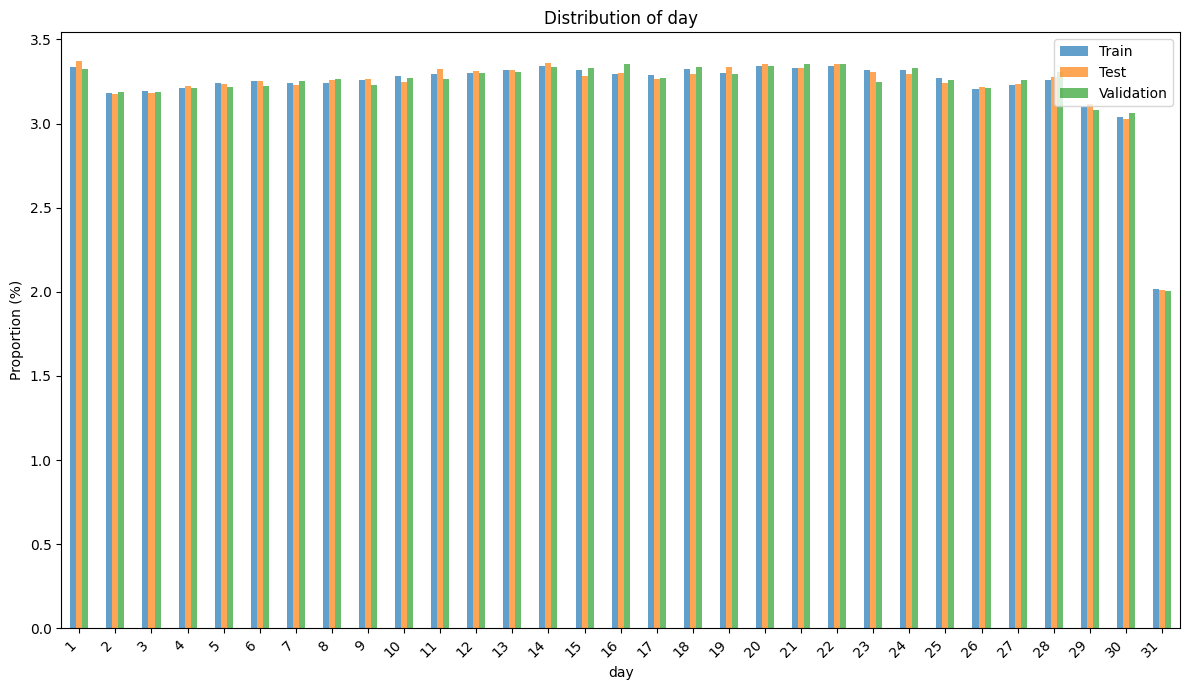

<Figure size 1200x700 with 0 Axes>

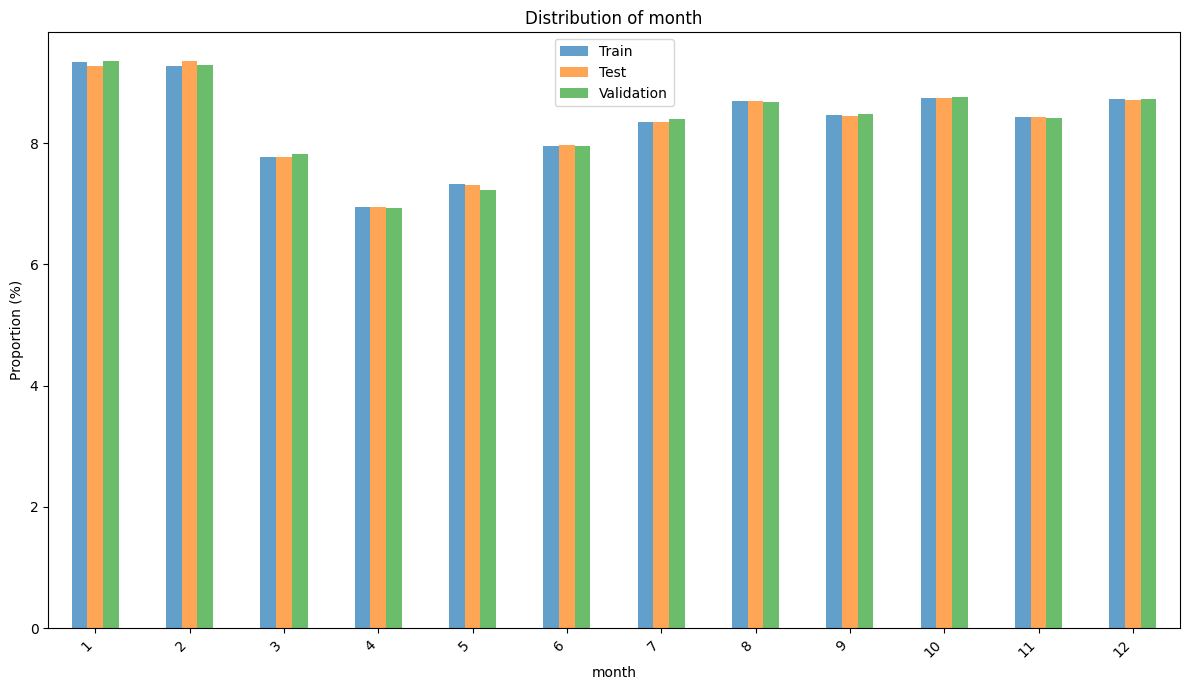

<Figure size 1200x700 with 0 Axes>

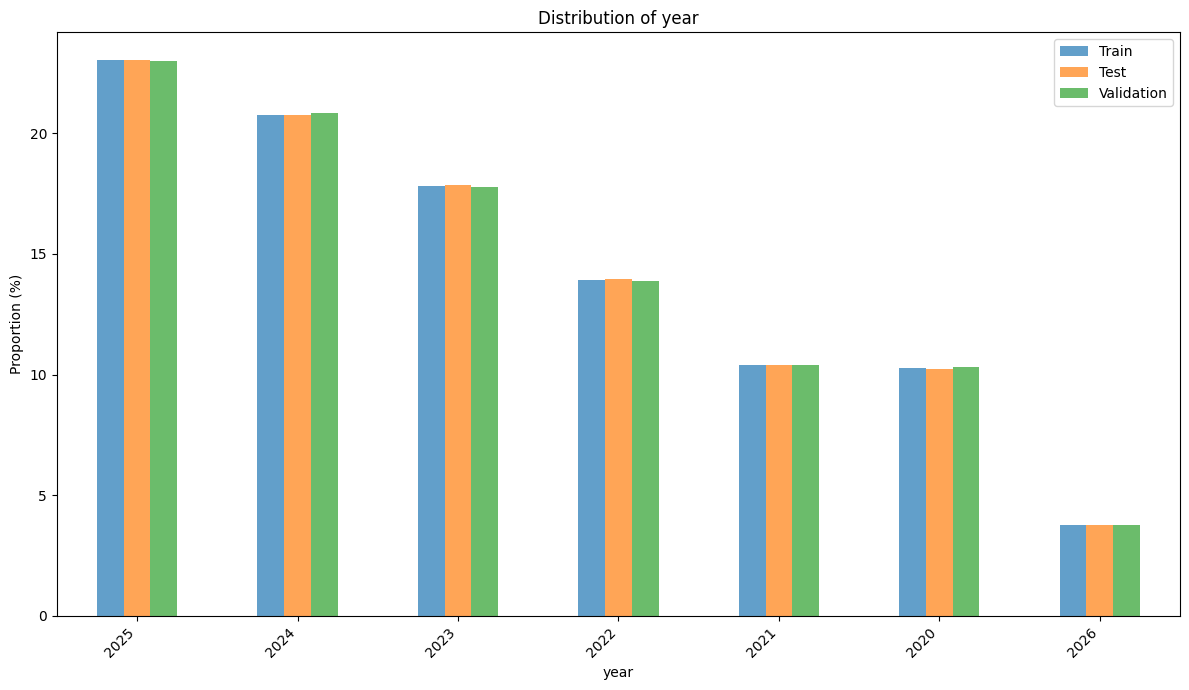

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

for col in ['pickup_ward', 'dropoff_ward', 'event_in_pickup_ward', 'hour', 'day_of_week', 'day', 'month', 'year']:

  train_proportions = X_train[col].value_counts(normalize=True) * 100
  test_proportions = X_test[col].value_counts(normalize=True) * 100
  val_proportions = X_val[col].value_counts(normalize=True) * 100

  # Combine proportions into a single DataFrame for grouped bar plot
  combined_proportions = pd.DataFrame({
      'Train': train_proportions,
      'Test': test_proportions,
      'Validation': val_proportions
  }).fillna(0) # Fill NaN values with 0 in case a category is missing in one split

  plt.figure(figsize=(12, 7))
  combined_proportions.plot(kind='bar', alpha=0.7, figsize=(12, 7), title=f'Distribution of {col}')

  plt.xlabel(col)
  plt.ylabel('Proportion (%)')
  plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
  plt.tight_layout() # Adjust layout to prevent labels from being cut off
  plt.show()

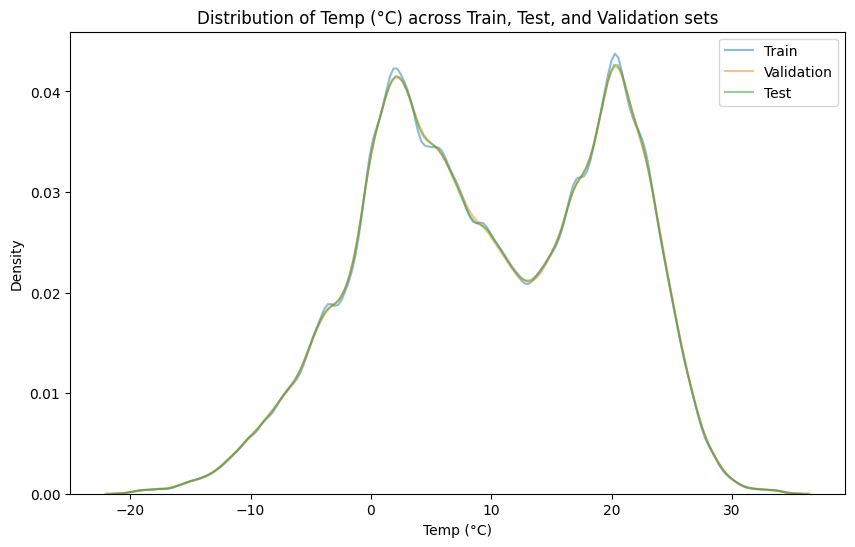

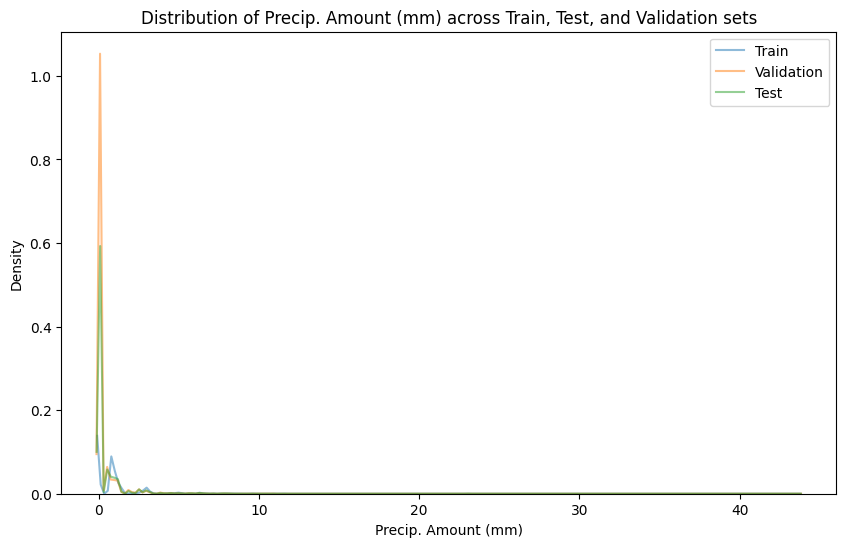

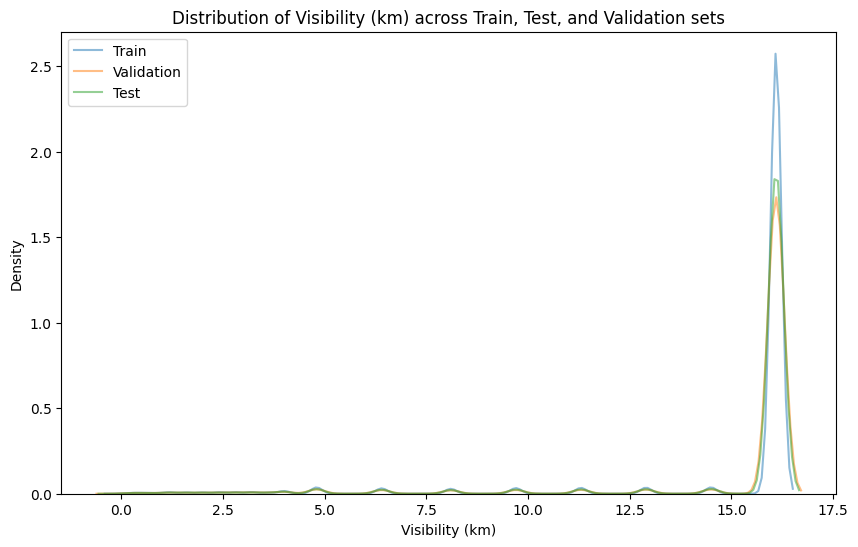

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

continuous_cols = ['Temp (°C)', 'Precip. Amount (mm)', 'Visibility (km)']

for col in continuous_cols:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(X_train[col], label='Train', fill=False, alpha=0.5)
    sns.kdeplot(X_val[col], label='Validation', fill=False, alpha=0.5)
    sns.kdeplot(X_test[col], label='Test', fill=False, alpha=0.5)
    plt.title(f'Distribution of {col} across Train, Test, and Validation sets')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.show()

In [ ]:
X_train['Precip. Amount (mm)'][X_train['Precip. Amount (mm)'] != 0].describe()

,Precip. Amount (mm)
count,307164.000000
mean,1.304259
std,2.213510
min,0.100000
25%,0.200000
50%,0.800000
75%,1.500000
max,43.700000


In [ ]:
display(y_train.describe())

display(y_test.describe())

,total_time
count,4.752941e+06
mean,2.048010e+01
std,8.801325e+00
min,1.000000e+00
25%,1.452000e+01
50%,1.847000e+01
75%,2.450000e+01
max,3.486730e+03


,total_time
count,950589.000000
mean,20.503557
std,8.424942
min,2.540000
25%,14.520000
50%,18.480000
75%,24.520000
max,521.670000


In [ ]:
df['year'].describe()

,year
count,6.337256e+06
mean,2.023126e+03
std,1.712051e+00
min,2.020000e+03
25%,2.022000e+03
50%,2.023000e+03
75%,2.025000e+03
max,2.026000e+03


# Training model

In [ ]:
import lightgbm as lgb

print("LightGBM GPU Support:", lgb.basic._LIB is not None)
print(lgb.__version__)


LightGBM GPU Support: True
4.6.0


In [ ]:
# model = lgb.LGBMRegressor(
#     device='gpu',
#     learning_rate= 0.04969632996842318, n_estimators= 2827, max_depth=10
# )
# eval_result = {}

# model.fit(
#     X_train, y_train,
#     eval_set=[(X_val, y_val)],
#     callbacks=[
#         lgb.early_stopping(stopping_rounds=100),
#         lgb.record_evaluation(eval_result=eval_result)
#     ]
# )



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
# y_pred = model.predict(X_test)

# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)

# print(f"Test MSE: {mse}")
# print(f"Test R2 Score: {r2}")

## Tuning Hyperparameters

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 34.8 MB/s eta 0:00:00


In [ ]:
import optuna
ESTIMATORS = 2000

def objective(trial: optuna.Trial):
  params = {
      "device": "gpu",
      "verbosity": -1,
      "n_estimators": ESTIMATORS,
      "max_depth": 8,
      "subsample_freq": 1,
      "learning_rate": trial.suggest_float("learning_rate", 0.1, 0.3, log=True),
      "num_leaves": trial.suggest_int("num_leaves", 31, 255),
      "min_child_samples": trial.suggest_int("min_child_samples", 100, 1000),
      "subsample": trial.suggest_float("subsample", 0.6, 1.0),
      "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
      "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
  }

  model = lgb.LGBMRegressor(**params)

  model.fit(
      X_train, y_train,
      eval_set=[(X_val, y_val)],
      callbacks=[
          lgb.early_stopping(stopping_rounds=50),
          lgb.log_evaluation(period=100),
      ]
  )

  return model.best_score_['valid_0']['l2']

study = optuna.create_study()

study.optimize(objective, n_trials=30 )

print("Best trial:")
trial = study.best_trial
print("  Value: {}".format(trial.value))
print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

[I 2026-05-06 00:20:52,017] A new study created in memory with name: no-name-d0caa9e7-4276-4ae5-bba6-1547925eeb76


Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 9.52625
[200]	valid_0's l2: 8.01803
[300]	valid_0's l2: 7.52936
[400]	valid_0's l2: 7.23068
[500]	valid_0's l2: 7.04313
[600]	valid_0's l2: 6.91496
[700]	valid_0's l2: 6.79704
[800]	valid_0's l2: 6.71002
[900]	valid_0's l2: 6.62762
[1000]	valid_0's l2: 6.54892
[1100]	valid_0's l2: 6.49518
[1200]	valid_0's l2: 6.45522
[1300]	valid_0's l2: 6.42052
[1400]	valid_0's l2: 6.38718
[1500]	valid_0's l2: 6.35287
[1600]	valid_0's l2: 6.32652
[1700]	valid_0's l2: 6.3042
[1800]	valid_0's l2: 6.28327
[1900]	valid_0's l2: 6.25726
[2000]	valid_0's l2: 6.24143
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l2: 6.24143


[I 2026-05-06 00:36:07,793] Trial 0 finished with value: 6.241427094723761 and parameters: {'learning_rate': 0.20317538105236593, 'num_leaves': 198, 'min_child_samples': 267, 'subsample': 0.9769902234373535, 'colsample_bytree': 0.9122664666820892, 'reg_lambda': 0.14850700011895093}. Best is trial 0 with value: 6.241427094723761.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 9.41923
[200]	valid_0's l2: 7.96871
[300]	valid_0's l2: 7.5085
[400]	valid_0's l2: 7.25026
[500]	valid_0's l2: 7.07351
[600]	valid_0's l2: 6.9541
[700]	valid_0's l2: 6.86093
[800]	valid_0's l2: 6.79507
[900]	valid_0's l2: 6.73822
[1000]	valid_0's l2: 6.69371
[1100]	valid_0's l2: 6.65432
[1200]	valid_0's l2: 6.61961
[1300]	valid_0's l2: 6.5888
[1400]	valid_0's l2: 6.56668
Early stopping, best iteration is:
[1437]	valid_0's l2: 6.55981


[I 2026-05-06 00:49:41,524] Trial 1 finished with value: 6.559809615722981 and parameters: {'learning_rate': 0.23512833958255483, 'num_leaves': 190, 'min_child_samples': 199, 'subsample': 0.688637891911874, 'colsample_bytree': 0.6908714845186579, 'reg_lambda': 8.182440953107111}. Best is trial 0 with value: 6.241427094723761.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 9.62381
[200]	valid_0's l2: 8.16169
[300]	valid_0's l2: 7.70532
[400]	valid_0's l2: 7.44108
[500]	valid_0's l2: 7.24613
[600]	valid_0's l2: 7.09788
[700]	valid_0's l2: 6.9818
[800]	valid_0's l2: 6.89476
[900]	valid_0's l2: 6.83293
[1000]	valid_0's l2: 6.76151
[1100]	valid_0's l2: 6.70933
[1200]	valid_0's l2: 6.65081
[1300]	valid_0's l2: 6.61442
[1400]	valid_0's l2: 6.57165
[1500]	valid_0's l2: 6.53692
[1600]	valid_0's l2: 6.51442
[1700]	valid_0's l2: 6.48574
[1800]	valid_0's l2: 6.45702
[1900]	valid_0's l2: 6.43257
[2000]	valid_0's l2: 6.41654
Did not meet early stopping. Best iteration is:
[1997]	valid_0's l2: 6.41559


[I 2026-05-06 01:06:59,354] Trial 2 finished with value: 6.415594037703363 and parameters: {'learning_rate': 0.19232315304004655, 'num_leaves': 216, 'min_child_samples': 651, 'subsample': 0.824284457708428, 'colsample_bytree': 0.8060199904893397, 'reg_lambda': 0.0012012582690329712}. Best is trial 0 with value: 6.241427094723761.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 13.5358
[200]	valid_0's l2: 10.4076
[300]	valid_0's l2: 9.42579
[400]	valid_0's l2: 8.86442
[500]	valid_0's l2: 8.53014
[600]	valid_0's l2: 8.22576
[700]	valid_0's l2: 7.96067
[800]	valid_0's l2: 7.78381
[900]	valid_0's l2: 7.66642
[1000]	valid_0's l2: 7.56166
[1100]	valid_0's l2: 7.45597
[1200]	valid_0's l2: 7.36967
[1300]	valid_0's l2: 7.29761
[1400]	valid_0's l2: 7.23074
[1500]	valid_0's l2: 7.17175
[1600]	valid_0's l2: 7.12653
[1700]	valid_0's l2: 7.08706
[1800]	valid_0's l2: 7.05828
[1900]	valid_0's l2: 7.01577
[2000]	valid_0's l2: 6.97979
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l2: 6.97979


[I 2026-05-06 01:15:52,839] Trial 3 finished with value: 6.97978928642044 and parameters: {'learning_rate': 0.20742639370094915, 'num_leaves': 40, 'min_child_samples': 266, 'subsample': 0.754202782629525, 'colsample_bytree': 0.7621442190580793, 'reg_lambda': 0.04297663731807014}. Best is trial 0 with value: 6.241427094723761.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 12.8851
[200]	valid_0's l2: 9.48086
[300]	valid_0's l2: 8.72525


In [ ]:
import joblib

# 1. Train on best params
best_params = study.best_trial.params

model = lgb.LGBMRegressor(
    **best_params,
    device='gpu',
    verbosity=-1,
    subsample_freq=1,
    n_estimators=ESTIMATORS,
    max_depth=8
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100),
    ]
)

# 2. Evaluate on test set
y_pred = model.predict(X_test)
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R2:", r2_score(y_test, y_pred))

# 3. Save and download
joblib.dump(model, "lgbm_model.pkl")

from google.colab import files
files.download("lgbm_model.pkl")
